# 雪球权价比 1/3/5 日回看对比

## tl;dr

- **保留 5 日为线上默认。** 1 日版明显受短期噪声影响；3 日版可以影子观察，但没有稳定胜过 5 日。
- 生产门槛下，5 日持有净超额：1 日 **-0.99%**、3 日 **+0.54%**、5 日 **+0.45%**（均扣 20 bps）。3 日与 5 日在相同日期配对后，3 日低 **0.06%**（p=0.977），实质打平。
- 5 日版的 5 日 Rank IC 为 **0.051**，高于 3 日的 **0.040** 和 1 日的 **0.024**；10 日持有净超额也只有 5 日版保持为正。

## Context & Methods

比较对象是雪球活跃组合持仓的权价比：`综合权重倍数 / 股价倍数`，分别以第 1、3、5 个更早的有效快照日为基准。持仓快照在收盘后生成，统一按下一交易日开盘进入，远期收益计算到第 1/3/5/10 个交易日收盘。

生产门槛复现当前配置：排名 Top100、至少 5 个组合持有、组合数增加至少 1、总权重增加、权重倍数 >1.05、股价倍数 <1、权价比 1.23–6；强势新进沿用 Top30 且至少 10 个组合。净超额为信号组合收益减同日共同股票池收益，再扣 20 bps 往返成本。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from lab.compare_xueqiu_weight_price_lookbacks import analyze, write_outputs

OUTPUT = Path('lab/output/xueqiu_weight_price_lookback_comparison_20260701_20260826')
result = analyze()
write_outputs(result, OUTPUT)
signal_metrics = result['signal_metrics']
factor_metrics = result['factor_metrics']
topn_metrics = result['topn_metrics']
pairwise = result['pairwise']
overlap = result['overlap']
result['metadata']

{'lookbacks': [1, 3, 5],
 'common_stock_days': 3474,
 'common_snapshot_dates': 38,
 'common_symbols': 212,
 'snapshot_min': '2026-07-02',
 'snapshot_max': '2026-08-25',
 'cost_bps': 20.0,
 'holdings_valid_from': '2026-06-25',
 'missing_snapshot_trading_days': ['2026-08-05'],
 'production_parameters': {'min_ratio': 1.23,
  'max_ratio': 6.0,
  'min_holding_cubes': 5,
  'holding_cube_increase': 1,
  'current_rank_limit': 100,
  'new_entry_rank_limit': 30,
  'new_entry_min_cubes': 10}}

## Data

三种回看周期只保留都可计算的共同股票日。雪球异常榜单边界按线上逻辑设为 2026-06-25；2026-08-05 缺少快照，因此“日前”始终表示更早的有效快照日，而不是自然日。

In [2]:
quality = pd.DataFrame([result['metadata']]).T.rename(columns={0: 'value'})
display(quality)

,value
lookbacks,"[1, 3, 5]"
common_stock_days,3474
common_snapshot_dates,38
common_symbols,212
snapshot_min,2026-07-02
snapshot_max,2026-08-25
cost_bps,20.0
holdings_valid_from,2026-06-25
missing_snapshot_trading_days,[2026-08-05]
production_parameters,"{'min_ratio': 1.23, 'max_ratio': 6.0, 'min_hol..."


## Results

### 生产门槛信号

5 日持有是当前策略最直接的观察窗口。1 日版在 5 日和 10 日窗口均为负；3 日与 5 日在 5 日窗口接近，但 5 日版的 10 日延续性更好。

In [3]:
cols = ['lookback_days', 'horizon_days', 'signal_instances', 'signal_dates',
        'avg_signals_per_date', 'net_excess', 'net_excess_win_rate', 'net_excess_p']
table = signal_metrics[signal_metrics.horizon_days.isin([5, 10])][cols].copy()
table['net_excess'] = table['net_excess'].map(lambda x: f'{x:.2%}')
table['net_excess_win_rate'] = table['net_excess_win_rate'].map(lambda x: f'{x:.2%}')
table['net_excess_p'] = table['net_excess_p'].map(lambda x: f'{x:.3f}')
display(table)

,lookback_days,horizon_days,signal_instances,signal_dates,avg_signals_per_date,net_excess,net_excess_win_rate,net_excess_p
2,1,5,166,31,5.354839,-0.99%,48.39%,0.408
3,1,10,137,26,5.269231,-3.41%,34.62%,0.055
6,3,5,172,33,5.212121,0.54%,51.52%,0.691
7,3,10,146,28,5.214286,-0.02%,35.71%,0.994
10,5,5,201,31,6.483871,0.45%,58.06%,0.624
11,5,10,175,26,6.730769,0.32%,65.38%,0.765


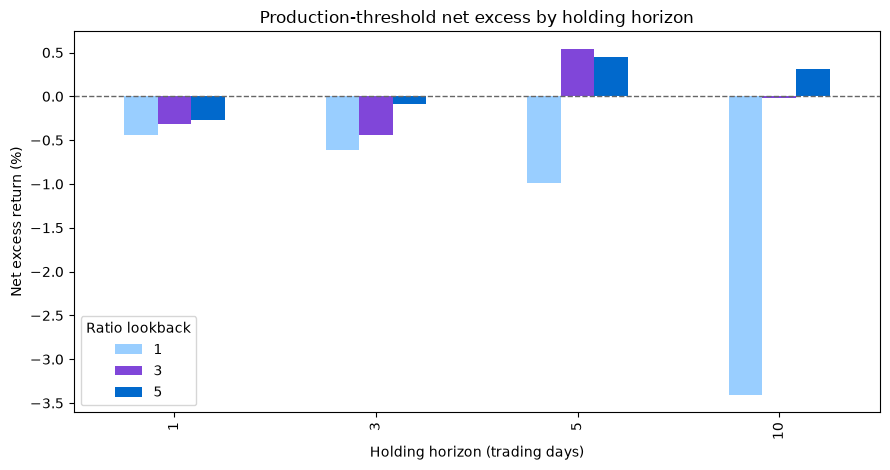

In [4]:
chart = signal_metrics[signal_metrics.horizon_days.isin([1, 3, 5, 10])].pivot(
    index='horizon_days', columns='lookback_days', values='net_excess'
) * 100
ax = chart.plot(kind='bar', figsize=(9, 4.8), color=['#99CEFF', '#8046D9', '#0169CC'])
ax.axhline(0, color='#666666', linewidth=1, linestyle='--')
ax.set_title('Production-threshold net excess by holding horizon')
ax.set_xlabel('Holding horizon (trading days)')
ax.set_ylabel('Net excess return (%)')
ax.legend(title='Ratio lookback')
plt.tight_layout()
plt.show()

### 连续因子与同日配对

Rank IC 和十分位多空差用于判断权价比本身的排序能力；同日配对差异避免某个版本因多覆盖一两个日期而虚高。

In [5]:
factor_5d = factor_metrics[factor_metrics.horizon_days == 5][[
    'lookback_days', 'cross_sections', 'rank_ic', 'rank_ic_positive_rate',
    'top_bottom_spread', 'top_bottom_spread_p'
]].copy()
factor_5d['rank_ic'] = factor_5d['rank_ic'].map(lambda x: f'{x:.3f}')
factor_5d['rank_ic_positive_rate'] = factor_5d['rank_ic_positive_rate'].map(lambda x: f'{x:.2%}')
factor_5d['top_bottom_spread'] = factor_5d['top_bottom_spread'].map(lambda x: f'{x:.2%}')
factor_5d['top_bottom_spread_p'] = factor_5d['top_bottom_spread_p'].map(lambda x: f'{x:.3f}')
display(factor_5d)
pairwise_3v5 = pairwise[(pairwise.left_lookback_days == 3) & (pairwise.right_lookback_days == 5)].copy()
pairwise_3v5['left_minus_right_net_excess'] = pairwise_3v5['left_minus_right_net_excess'].map(lambda x: f'{x:.2%}')
pairwise_3v5['difference_p'] = pairwise_3v5['difference_p'].map(lambda x: f'{x:.3f}')
display(pairwise_3v5)

,lookback_days,cross_sections,rank_ic,rank_ic_positive_rate,top_bottom_spread,top_bottom_spread_p
2,1,34,0.024,64.71%,0.97%,0.323
6,3,34,0.040,58.82%,1.34%,0.131
10,5,34,0.051,73.53%,1.43%,0.072


,horizon_days,left_lookback_days,right_lookback_days,common_dates,left_minus_right_net_excess,difference_p
2,1,3,5,34,-0.12%,0.819
5,3,3,5,32,-0.35%,0.749
8,5,3,5,30,-0.06%,0.977
11,10,3,5,25,-0.41%,0.872


### 信号重合度

3 日与 5 日的日均 Jaccard 仅约 19%，说明缩短回看期并非微调，而是会显著更换信号股票。

In [6]:
overlap_display = overlap.copy()
overlap_display['mean_daily_jaccard'] = overlap_display['mean_daily_jaccard'].map(lambda x: f'{x:.2%}')
display(overlap_display)

,left_lookback_days,right_lookback_days,dates,mean_daily_jaccard
0,1,3,38,12.11%
1,1,5,37,12.22%
2,3,5,38,17.76%


## Takeaways

1. **不切 1 日。** 短期噪声、5 日净超额和 10 日延续性均最差。
2. **5 日继续作为生产默认。** 它的连续排序能力最好，且 10 日信号延续性为正。
3. **3 日只做影子记录。** 它在未配对均值上略高，但相同日期配对后没有优势；等新增至少 3–6 个月样本，再用预先固定的参数复核，避免追逐两个月样本噪声。

## Caveats

- 有效快照历史仅约两个月，5 日远期比较只有 31–33 个日截面，除1日版相对5日版的10日配对差外，主差异均未达到常用统计显著性门槛。
- 多日远期收益彼此重叠，普通 t 检验仅作方向性参考，不应解读为独立观测的严格因果证据。
- 这是信号/因子有效性对比，不是对星澜叁号完整缓冲换仓、恐贪仓位和止盈状态机的逐笔资金曲线复刻。